In [ ]:
import hbsir
hbsir.setup(years=[1395])
table_1395 = hbsir.load_table("Expenditures", years=[1395])
print(table_1395.head())
table_1395 = hbsir.add_attribute(table_1395, name="Province")
table_1395 = hbsir.add_attribute(table_1395, name="County")
table_1395 = hbsir.add_attribute(table_1395, name="Urban_Rural")
hhinc_1395 = hbsir.load_table("employment_income", years=[1395])
members_1395 = hbsir.load_table("members_properties", years=[1395])

   Year           ID Table_Name  Commodity_Code Provision_Method Amount  \
0  1395  20001010534       food           11165         Purchase   24.0   
1  1395  20001010525       food           11112         Purchase  240.0   
2  1395  20001010525       food           11143         Purchase   24.0   
3  1395  20001010525       food           11151         Purchase  360.0   
4  1395  20001010525       food           11153         Purchase   24.0   

      Price  Gross_Expenditure  Net_Expenditure  
0   20000.0           480000.0         480000.0  
1  100000.0         24000000.0       24000000.0  
2   20000.0           480000.0         480000.0  
3   16000.0          5760000.0        5760000.0  
4   45000.0          1080000.0        1080000.0  


C:\Users\tadbirsabz\AppData\Local\Temp\ipykernel_5168\2193095105.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_income_1395 = df_1395.groupby("Education_Level")["Annual_Continuous_Income"].mean().reindex(valid_levels)


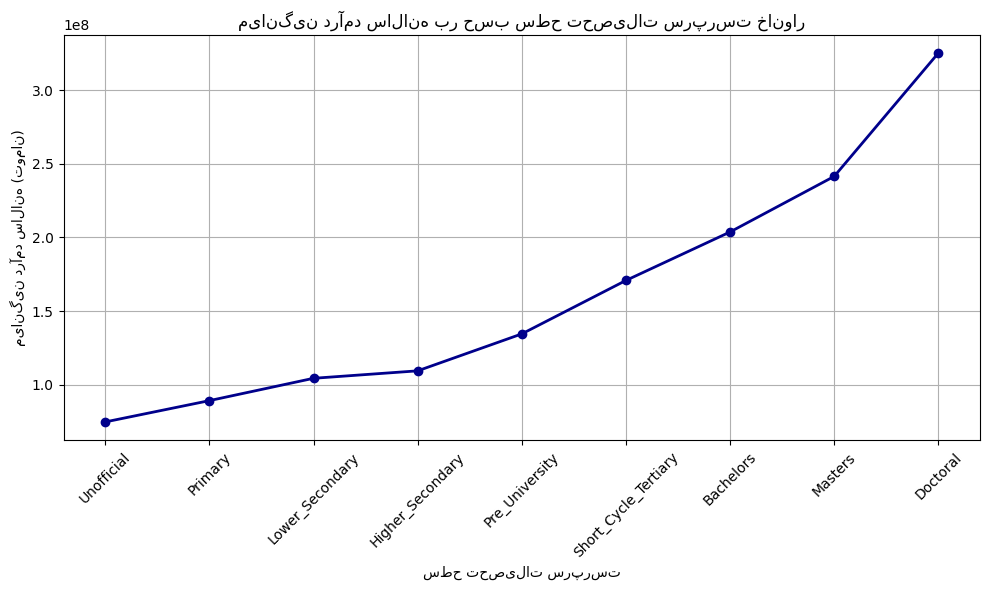

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

# لیست مرتب‌شده سطح تحصیلات
valid_levels = [
    "Unofficial",             
    "Primary",                
    "Lower_Secondary",        
    "Higher_Secondary",       
    "Pre_University",         
    "Short_Cycle_Tertiary",   
    "Bachelors",              
    "Masters",                
    "Doctoral"                
]

# فیلتر فقط سرپرست‌ها با سطح تحصیلات معتبر
df_1395 = members_1395[(members_1395["Member_Number"] == 1) & (members_1395["Education_Level"].isin(valid_levels))].copy()

# تبدیل به نوع مرتب Categorical
df_1395["Education_Level"] = pd.Categorical(df_1395["Education_Level"], categories=valid_levels, ordered=True)

# اضافه کردن درآمد سرپرست‌ها از hhinc
df_1395 = df_1395.merge(
    hhinc_1395[hhinc_1395["Member_Number"] == 1][["ID", "Annual_Continuous_Income"]],
    on="ID",
    how="left"
)

# حذف ردیف‌هایی که درآمد ندارن
df_1395 = df_1395.dropna(subset=["Annual_Continuous_Income"])

# محاسبه میانگین درآمد برای هر سطح تحصیل
mean_income_1395 = df_1395.groupby("Education_Level")["Annual_Continuous_Income"].mean().reindex(valid_levels)

# 📈 رسم نمودار
plt.figure(figsize=(10, 6))
plt.plot(mean_income_1395.index, mean_income_1395.values, marker='o', color='darkblue', linewidth=2)
plt.xlabel("سطح تحصیلات سرپرست")
plt.ylabel("میانگین درآمد سالانه (تومان)")
plt.title("میانگین درآمد سالانه بر حسب سطح تحصیلات سرپرست خانوار")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



---- مدل بدون تعامل ----
                               OLS Regression Results                               
Dep. Variable:     Annual_Continuous_Income   R-squared:                       0.251
Model:                                  OLS   Adj. R-squared:                  0.251
Method:                       Least Squares   F-statistic:                     2294.
Date:                      Tue, 12 Aug 2025   Prob (F-statistic):               0.00
Time:                              12:43:15   Log-Likelihood:            -2.6759e+05
No. Observations:                     13698   AIC:                         5.352e+05
Df Residuals:                         13695   BIC:                         5.352e+05
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------

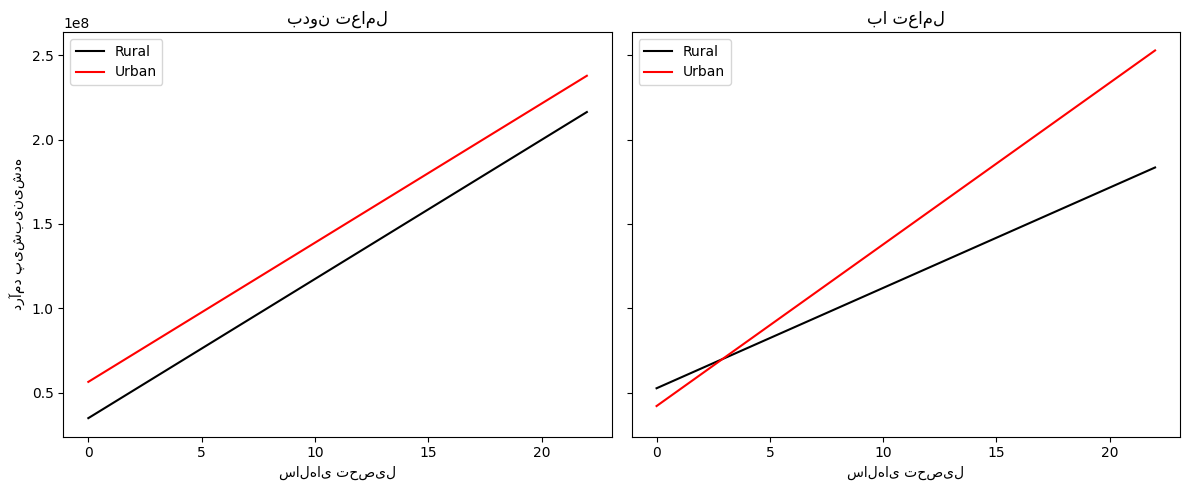

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# ----------------------
# 1. نگاشت سطح تحصیلات به سال تحصیل
# ----------------------
edu_map = {
    "Unofficial": 0,
    "Primary": 5,
    "Lower_Secondary": 8,
    "Higher_Secondary": 12,
    "Pre_University": 13,
    "Short_Cycle_Tertiary": 14,
    "Bachelors": 16,
    "Masters": 18,
    "Doctoral": 22
}

# فیلتر فقط سرپرست‌ها با سطح تحصیلات معتبر
df = members_1395[(members_1395["Member_Number"] == 1) & 
             (members_1395["Education_Level"].isin(valid_levels))].copy()

# افزودن سال تحصیل
# افزودن سال تحصیل و تبدیل به عدد
df["Years_Edu"] = df["Education_Level"].map(edu_map).astype(float)


# اضافه کردن درآمد
df = df.merge(
    hhinc_1395[hhinc_1395["Member_Number"] == 1][["ID", "Annual_Continuous_Income"]],
    on="ID", how="left"
)

# اضافه کردن شهری/روستایی
urban_rural = table_1395[["ID", "Urban_Rural"]].drop_duplicates()
df = df.merge(urban_rural, on="ID", how="left")

# حذف ردیف‌هایی که درآمد ندارند
df = df.dropna(subset=["Annual_Continuous_Income"])

# تبدیل Urban_Rural به ۰ و ۱
df["Urban"] = df["Urban_Rural"].apply(lambda x: 1 if str(x).lower() == "urban" else 0)

# ----------------------
# 2. مدل‌سازی
# ----------------------
# مدل بدون تعامل
model_no_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu + Urban", data=df).fit()

# مدل با تعامل
model_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu * Urban", data=df).fit()

print("\n---- مدل بدون تعامل ----")
print(model_no_inter.summary())

print("\n---- مدل با تعامل ----")
print(model_inter.summary())

# ----------------------
# 3. رسم نمودار
# ----------------------
# بازه تحصیلات برای پیش‌بینی
years_range = np.linspace(df["Years_Edu"].min(), df["Years_Edu"].max(), 100)

plot_df = pd.DataFrame({
    "Years_Edu": np.tile(years_range, 2),
    "Urban": np.repeat([0, 1], len(years_range))
})

# پیش‌بینی
plot_df["pred_no_inter"] = model_no_inter.predict(plot_df)
plot_df["pred_inter"] = model_inter.predict(plot_df)

# رسم
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# بدون تعامل
for u, color, label in [(0, "black", "Rural"), (1, "red", "Urban")]:
    subset = plot_df[plot_df["Urban"] == u]
    axes[0].plot(subset["Years_Edu"], subset["pred_no_inter"], color=color, label=label)

axes[0].set_title("بدون تعامل")
axes[0].set_xlabel("سال‌های تحصیل")
axes[0].set_ylabel("درآمد پیش‌بینی‌شده")
axes[0].legend()

# با تعامل
for u, color, label in [(0, "black", "Rural"), (1, "red", "Urban")]:
    subset = plot_df[plot_df["Urban"] == u]
    axes[1].plot(subset["Years_Edu"], subset["pred_inter"], color=color, label=label)

axes[1].set_title("با تعامل")
axes[1].set_xlabel("سال‌های تحصیل")
axes[1].legend()

plt.tight_layout()
plt.show()



=== پردازش سال 1396 ===

---- مدل بدون تعامل ----
                               OLS Regression Results                               
Dep. Variable:     Annual_Continuous_Income   R-squared:                       0.275
Model:                                  OLS   Adj. R-squared:                  0.275
Method:                       Least Squares   F-statistic:                     2575.
Date:                      Tue, 12 Aug 2025   Prob (F-statistic):               0.00
Time:                              14:13:29   Log-Likelihood:            -2.6686e+05
No. Observations:                     13552   AIC:                         5.337e+05
Df Residuals:                         13549   BIC:                         5.337e+05
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------

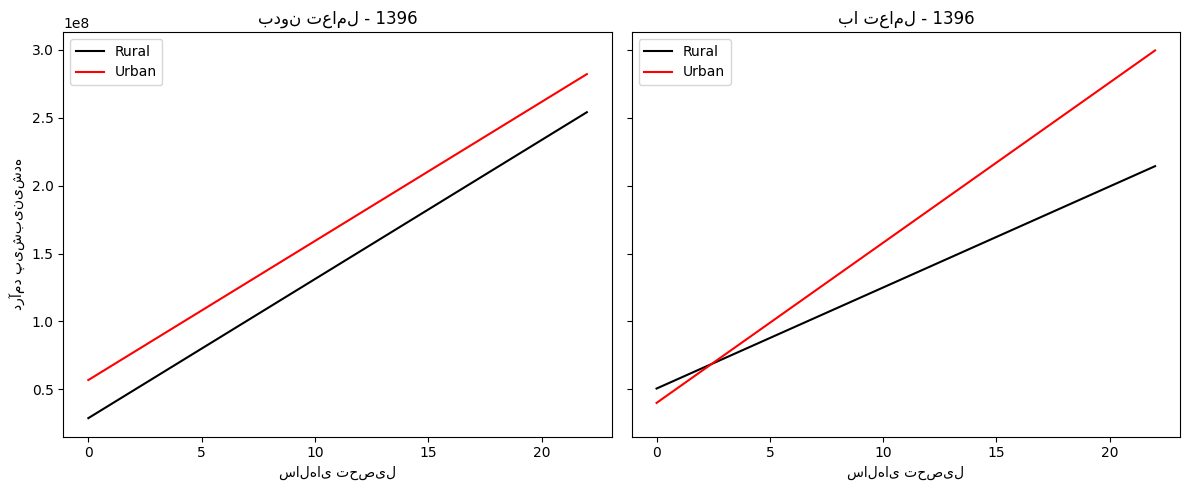


=== پردازش سال 1397 ===
⚠ خطا در پردازش سال 1397: File is not a zip file

=== پردازش سال 1398 ===

---- مدل بدون تعامل ----
                               OLS Regression Results                               
Dep. Variable:     Annual_Continuous_Income   R-squared:                       0.247
Model:                                  OLS   Adj. R-squared:                  0.246
Method:                       Least Squares   F-statistic:                     2306.
Date:                      Tue, 12 Aug 2025   Prob (F-statistic):               0.00
Time:                              14:14:02   Log-Likelihood:            -2.8322e+05
No. Observations:                     14098   AIC:                         5.664e+05
Df Residuals:                         14095   BIC:                         5.665e+05
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                 coef    

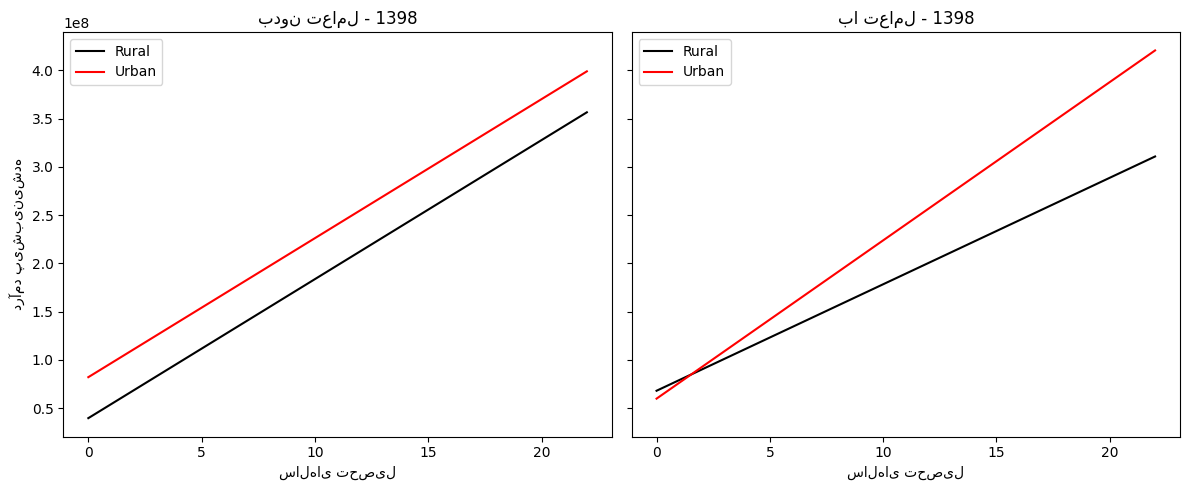


=== پردازش سال 1399 ===

---- مدل بدون تعامل ----
                               OLS Regression Results                               
Dep. Variable:     Annual_Continuous_Income   R-squared:                       0.241
Model:                                  OLS   Adj. R-squared:                  0.241
Method:                       Least Squares   F-statistic:                     2273.
Date:                      Tue, 12 Aug 2025   Prob (F-statistic):               0.00
Time:                              14:14:33   Log-Likelihood:            -2.9233e+05
No. Observations:                     14340   AIC:                         5.847e+05
Df Residuals:                         14337   BIC:                         5.847e+05
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------

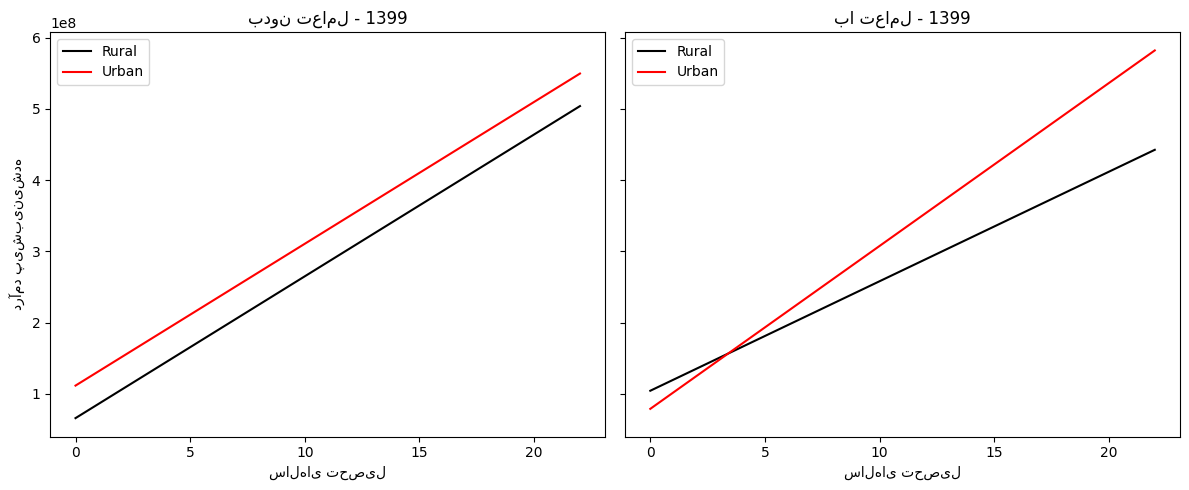


=== پردازش سال 1400 ===

---- مدل بدون تعامل ----
                               OLS Regression Results                               
Dep. Variable:     Annual_Continuous_Income   R-squared:                       0.214
Model:                                  OLS   Adj. R-squared:                  0.214
Method:                       Least Squares   F-statistic:                     1947.
Date:                      Tue, 12 Aug 2025   Prob (F-statistic):               0.00
Time:                              14:15:06   Log-Likelihood:            -2.9751e+05
No. Observations:                     14308   AIC:                         5.950e+05
Df Residuals:                         14305   BIC:                         5.951e+05
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------

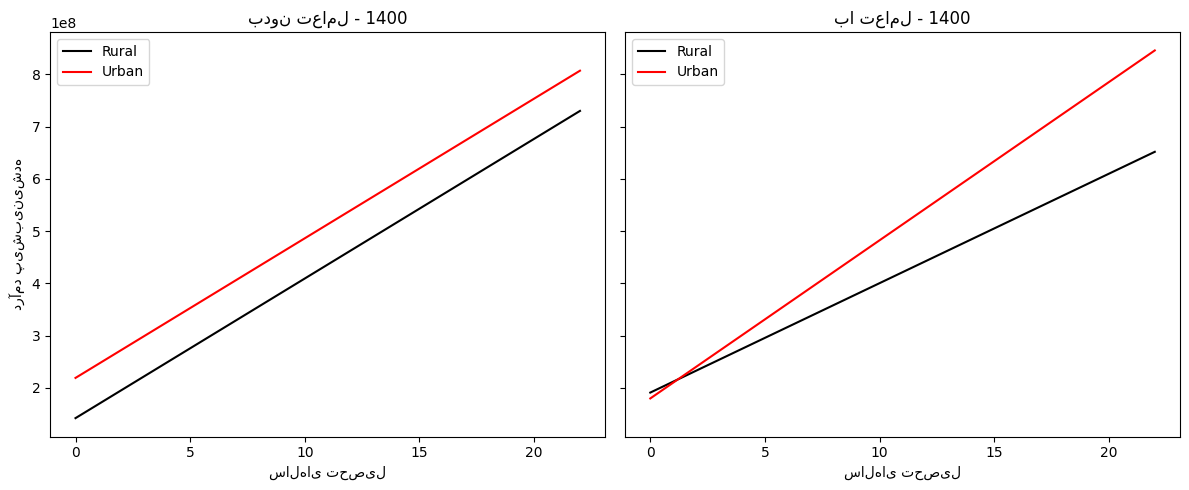


=== پردازش سال 1401 ===

---- مدل بدون تعامل ----
                               OLS Regression Results                               
Dep. Variable:     Annual_Continuous_Income   R-squared:                       0.171
Model:                                  OLS   Adj. R-squared:                  0.171
Method:                       Least Squares   F-statistic:                     1436.
Date:                      Tue, 12 Aug 2025   Prob (F-statistic):               0.00
Time:                              14:15:38   Log-Likelihood:            -2.9557e+05
No. Observations:                     13946   AIC:                         5.911e+05
Df Residuals:                         13943   BIC:                         5.912e+05
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------

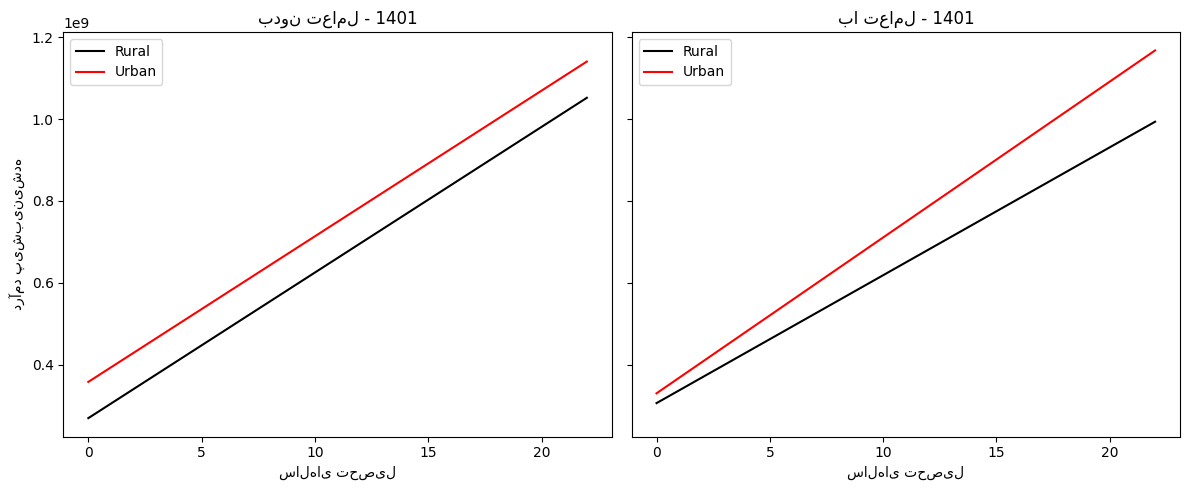

In [5]:
for year in range(1396, 1402):
    print(f"\n=== پردازش سال {year} ===")
    try:
        # ---------- بارگذاری داده‌ها ----------
        hbsir.setup(years=[year])
        table = hbsir.load_table("Expenditures", years=[year])
        table = hbsir.add_attribute(table, name="Province")
        table = hbsir.add_attribute(table, name="County")
        table = hbsir.add_attribute(table, name="Urban_Rural")

        hhinc = hbsir.load_table("employment_income", years=[year])
        members = hbsir.load_table("members_properties", years=[year])

        # ---------- پردازش ----------
        df = members[(members["Member_Number"] == 1) & 
                     (members["Education_Level"].isin(valid_levels))].copy()
        df["Years_Edu"] = df["Education_Level"].map(edu_map).astype(float)

        df = df.merge(
            hhinc[hhinc["Member_Number"] == 1][["ID", "Annual_Continuous_Income"]],
            on="ID", how="left"
        )

        urban_rural = table[["ID", "Urban_Rural"]].drop_duplicates()
        df = df.merge(urban_rural, on="ID", how="left")

        df = df.dropna(subset=["Annual_Continuous_Income"])
        df["Urban"] = df["Urban_Rural"].apply(lambda x: 1 if str(x).lower() == "urban" else 0)

        # ---------- مدل ----------
        model_no_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu + Urban", data=df).fit()
        model_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu * Urban", data=df).fit()

        print("\n---- مدل بدون تعامل ----")
        print(model_no_inter.summary())

        print("\n---- مدل با تعامل ----")
        print(model_inter.summary())

        # ---------- نمودار ----------
        years_range = np.linspace(df["Years_Edu"].min(), df["Years_Edu"].max(), 100)
        plot_df = pd.DataFrame({
            "Years_Edu": np.tile(years_range, 2),
            "Urban": np.repeat([0, 1], len(years_range))
        })
        plot_df["pred_no_inter"] = model_no_inter.predict(plot_df)
        plot_df["pred_inter"] = model_inter.predict(plot_df)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
        for u, color, label in [(0, "black", "Rural"), (1, "red", "Urban")]:
            subset = plot_df[plot_df["Urban"] == u]
            axes[0].plot(subset["Years_Edu"], subset["pred_no_inter"], color=color, label=label)
            axes[1].plot(subset["Years_Edu"], subset["pred_inter"], color=color, label=label)

        axes[0].set_title(f"بدون تعامل - {year}")
        axes[0].set_xlabel("سال‌های تحصیل")
        axes[0].set_ylabel("درآمد پیش‌بینی‌شده")
        axes[0].legend()

        axes[1].set_title(f"با تعامل - {year}")
        axes[1].set_xlabel("سال‌های تحصیل")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"⚠ خطا در پردازش سال {year}: {e}")
        continue
